# Grupo 4

## Integrantes del equipo:
* PB252919 Daniel Roberto Portillo Belloso
* GZ130034 Eduardo Andrés Galicia Zavaleta
* HR150875 Fernando José Hernández Rodríguez
* ZM252743 Francisco Ramon Zuñiga Martinez
* HV252954 William Alexander Huezo Vasquez


# Análisis de Compras de Clientes - Dataset de Kaggle  

Cada equipo deberá seleccionar un conjunto de datos que contenga, como mínimo, una variable temporal, tres variables cualitativas y tres variables cuantitativas. A partir de este dataset, deberán realizar las siguientes actividades:  

Variable temporal: invoice_date  
Variables cualitativas: gender, category, payment_method, shopping_mall  
Variables cuantitativas: age, quantity, price  

a. Formular al menos cinco preguntas de negocio relevantes.  
b. Desarrollar visualizaciones en Python que permitan responder a las preguntas planteadas.  
c. Presentar el cuaderno de trabajo (notebook) con el desarrollo completo.  
d. Entregar un informe en formato PDF que documente el análisis realizado, las visualizaciones y las conclusiones obtenidas.  
e. Subir el dataset.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_shopping_data.csv')

#conversion a fecha hora
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


## Preguntas de Negocio

1. ¿Cómo han evolucionado los ingresos y el volumen de ventas por categoría de producto a lo largo del tiempo (mensual y trimestral) entre 2021 y 2023, y se observan patrones de estacionalidad o crecimiento/decrecimiento significativos?
2. ¿Cuáles son los centros comerciales de mayor rendimiento en términos de ingresos totales y cantidad de productos vendidos, y cómo se distribuye la contribución de cada categoría de producto dentro de estos centros?
3. ¿Cuáles son las 5 categorías de productos más vendidas en términos de cantidad y las 5 más rentables en términos de ingresos, y existe alguna correlación entre la cantidad vendida y el precio promedio por unidad en estas categorías?
4. ¿Cómo impacta el precio unitario en la cantidad de productos vendidos dentro de cada categoría, y existen rangos de precios óptimos que maximizan el volumen de ventas o los ingresos?
5. ¿Existen diferencias significativas en el gasto promedio por transacción y en las categorías de productos preferidas entre hombres y mujeres de diferentes grupos de edad, y cómo influye el método de pago utilizado en estos patrones de compra?


In [60]:
# Columna de total por transacción
df['total'] = df['quantity'] * df['price']

# Validar nulos
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
total             0
dtype: int64

## 1. ¿Cómo han evolucionado los ingresos y el volumen de ventas por categoría de producto a lo largo del tiempo (mensual y trimestral) entre 2021 y 2023, y se observan patrones de estacionalidad o crecimiento/decrecimiento significativos?


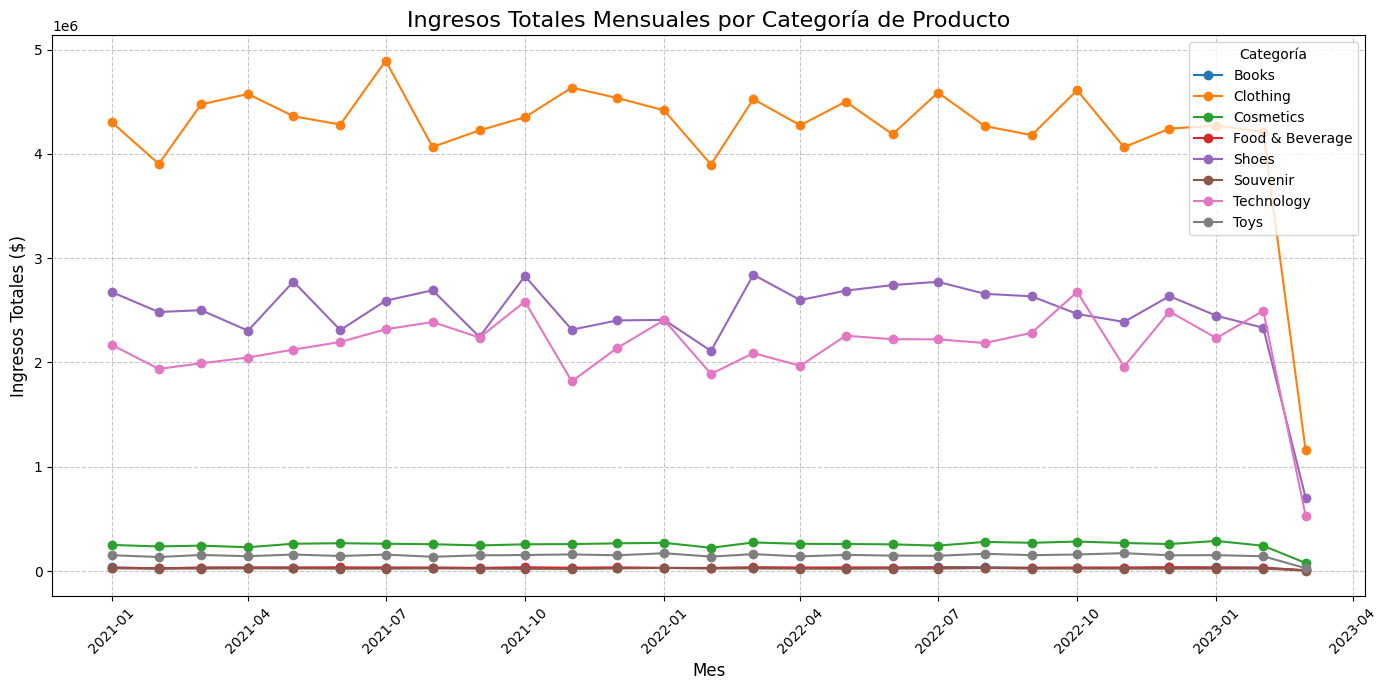

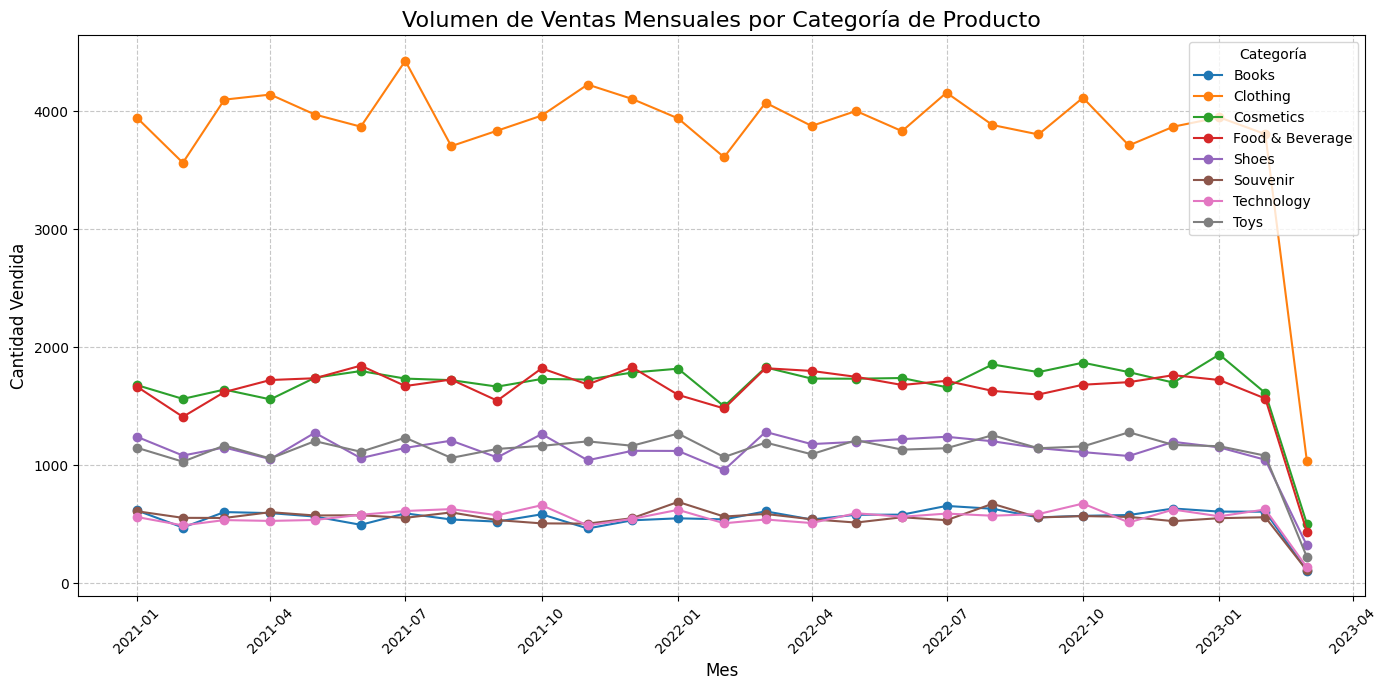

In [61]:
# Preparar datos para las visualizaciones
df['invoice_month'] = df['invoice_date'].dt.to_period('M')

# Gráfico de Ingresos Totales por Categoría
income_over_time = df.groupby(['invoice_month', 'category'])['total'].sum().unstack()
income_over_time.index = income_over_time.index.to_timestamp()

plt.figure(figsize=(14, 7))
for category in income_over_time.columns:
    plt.plot(income_over_time.index, income_over_time[category], marker='o', label=category)

plt.title('Ingresos Totales Mensuales por Categoría de Producto', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Categoría')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Gráfico de Volumen de Ventas por Categoría
quantity_over_time = df.groupby(['invoice_month', 'category'])['quantity'].sum().unstack()
quantity_over_time.index = quantity_over_time.index.to_timestamp()

plt.figure(figsize=(14, 7))
for category in quantity_over_time.columns:
    plt.plot(quantity_over_time.index, quantity_over_time[category], marker='o', label=category)

plt.title('Volumen de Ventas Mensuales por Categoría de Producto', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Categoría')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 2. ¿Cuáles son los centros comerciales de mayor rendimiento en términos de ingresos totales y cantidad de productos vendidos, y cómo se distribuye la contribución de cada categoría de producto dentro de estos centros?

In [62]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Análisis de rendimiento por centro comercial
mall_performance = df.groupby('shopping_mall').agg({
    'total': 'sum',
    'quantity': 'sum'
}).reset_index()

# Ordenar por ingresos totales (descendente)
mall_performance = mall_performance.sort_values('total', ascending=False)

# Crear subgráficos para barras
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Ingresos Totales por Centro Comercial', 'Cantidad Total de Productos Vendidos por Centro Comercial'),
    vertical_spacing=0.15
)

# Gráfico de barras para ingresos
fig.add_trace(
    go.Bar(
        x=mall_performance['shopping_mall'],
        y=mall_performance['total'],
        name='Ingresos Totales',
        marker_color='#2E86C1',
        text=[f'${x:,.0f}' for x in mall_performance['total']],
        textposition='outside'
    ),
    row=1, col=1
)

# Gráfico de barras para cantidad
fig.add_trace(
    go.Bar(
        x=mall_performance['shopping_mall'],
        y=mall_performance['quantity'],
        name='Cantidad Total',
        marker_color='#28B463',
        text=[f'{x:,}' for x in mall_performance['quantity']],
        textposition='outside'
    ),
    row=2, col=1
)

# Actualizar layout
fig.update_layout(
    height=800,
    title_text='Rendimiento de Centros Comerciales',
    showlegend=False
)

# Rotar etiquetas del eje X
fig.update_xaxes(tickangle=45)

fig.show()

# Preparar datos para el treemap
# Agrupar por centro comercial y categoría
treemap_data = df.groupby(['shopping_mall', 'category']).agg({
    'total': 'sum',
    'quantity': 'sum'
}).reset_index()

# Crear treemap para ingresos
fig_treemap_income = px.treemap(
    treemap_data,
    path=['shopping_mall', 'category'],
    values='total',
    title='Distribución de Ingresos por Centro Comercial y Categoría',
    color='total',
    color_continuous_scale='Viridis',
    hover_data=['quantity']
)

fig_treemap_income.update_layout(height=600)
fig_treemap_income.show()

# Crear treemap para cantidad
fig_treemap_quantity = px.treemap(
    treemap_data,
    path=['shopping_mall', 'category'],
    values='quantity',
    title='Distribución de Cantidad de Productos por Centro Comercial y Categoría',
    color='quantity',
    color_continuous_scale='Plasma',
    hover_data=['total']
)

fig_treemap_quantity.update_layout(height=600)
fig_treemap_quantity.show()

# Mostrar el top 10 de centros comerciales
print("Top 10 Centros Comerciales por Ingresos:")
print(mall_performance.head(10)[['shopping_mall', 'total', 'quantity']])

Top 10 Centros Comerciales por Ingresos:
       shopping_mall        total  quantity
5   Mall of Istanbul  50872481.68     60114
4             Kanyon  50554231.10     59457
6          Metrocity  37302787.33     44894
7       Metropol AVM  25379913.19     30530
3       Istinye Park  24618827.68     29465
9       Zorlu Center  12901053.82     15234
0        Cevahir AVM  12645138.20     14949
8     Viaport Outlet  12521339.72     14716
1  Emaar Square Mall  12406100.29     14501
2     Forum Istanbul  12303921.24     14852


## 3. ¿Cuáles son las 5 categorías de productos más vendidas en términos de cantidad y las 5 más rentables en términos de ingresos, y existe alguna correlación entre la cantidad vendida y el precio promedio por unidad en estas categorías?


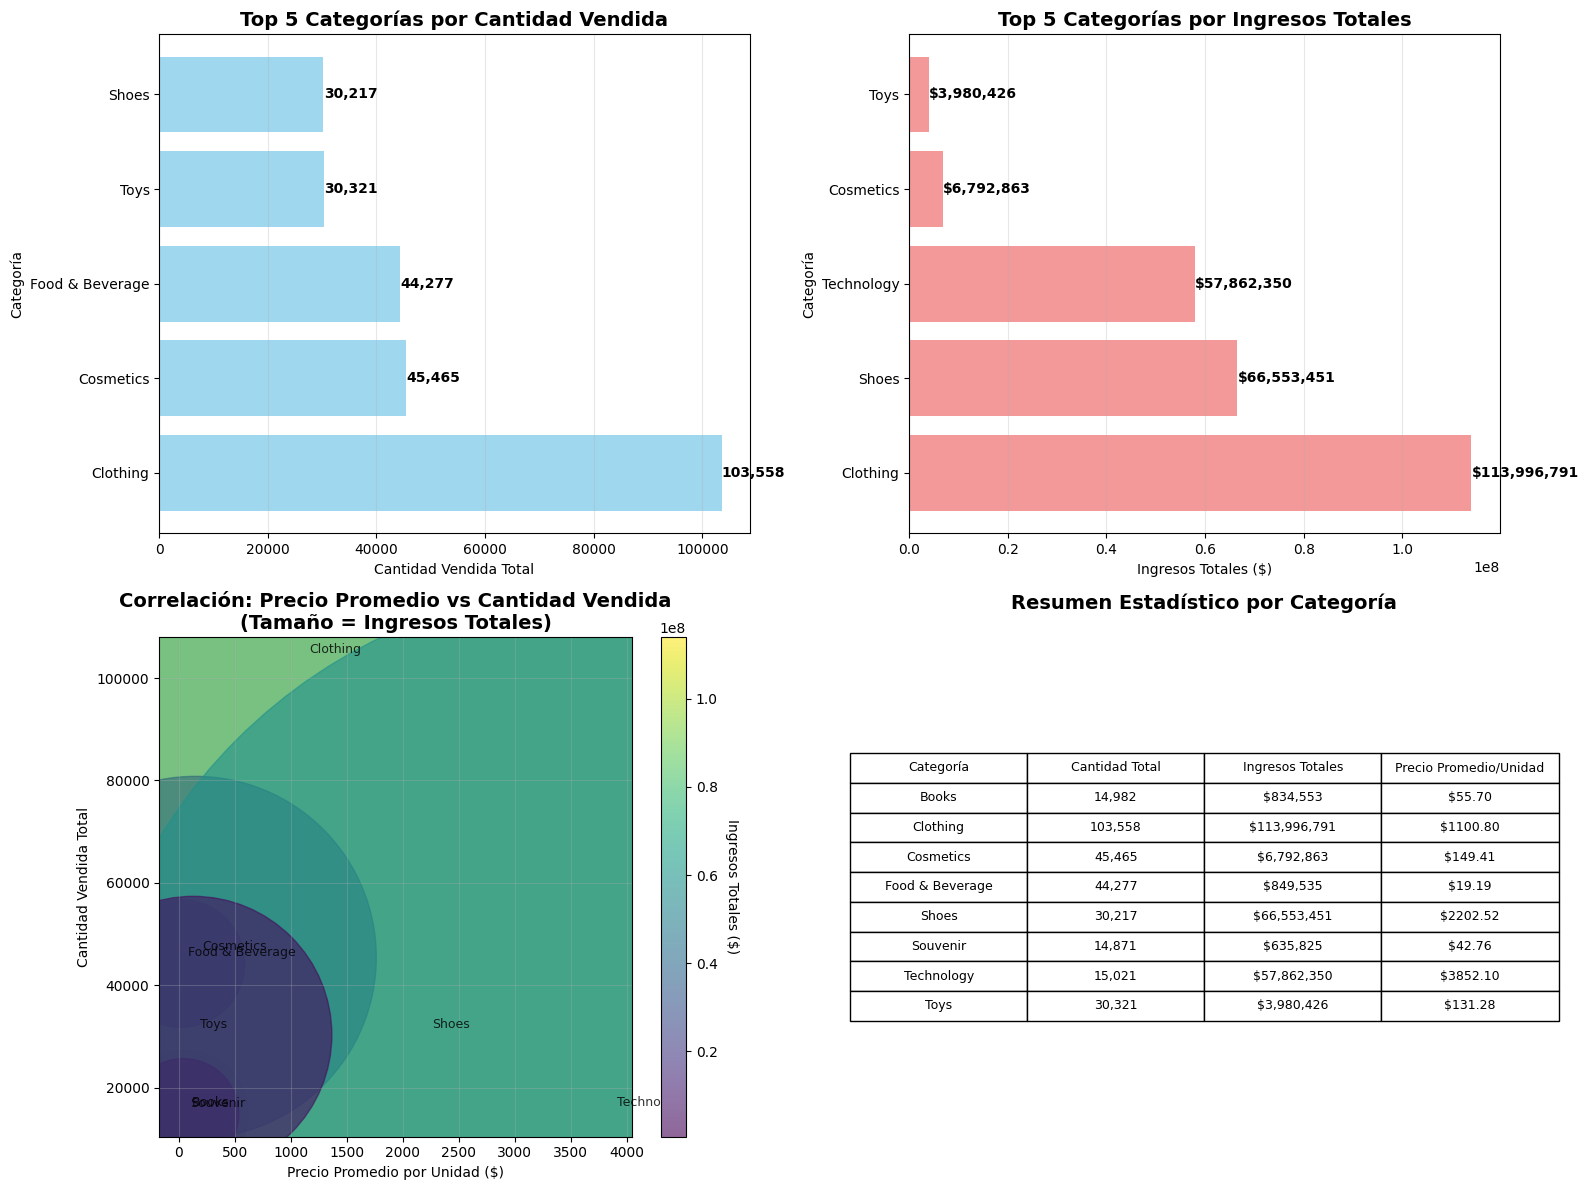


Coeficiente de Correlación entre Precio Promedio y Cantidad Vendida: -0.1052
Correlación débil: No hay una relación clara entre precio y cantidad

Top 5 Categorías por Cantidad:
       category  quantity        total
       Clothing    103558 113996791.04
      Cosmetics     45465   6792862.90
Food & Beverage     44277    849535.05
           Toys     30321   3980426.24
          Shoes     30217  66553451.47

Top 5 Categorías por Ingresos:
  category  quantity        total
  Clothing    103558 113996791.04
     Shoes     30217  66553451.47
Technology     15021  57862350.00
 Cosmetics     45465   6792862.90
      Toys     30321   3980426.24


In [63]:
# Análisis de categorías por cantidad e ingresos
category_analysis = df.groupby('category').agg({
    'quantity': 'sum',
    'total': 'sum'
}).reset_index()

# Calcular precio promedio por unidad
category_analysis['precio_promedio_unidad'] = category_analysis['total'] / category_analysis['quantity']

# Crear figura con subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 5 categorías por cantidad vendida (Gráfico de barras horizontal)
top5_quantity = category_analysis.nlargest(5, 'quantity')
ax1.barh(top5_quantity['category'], top5_quantity['quantity'], color='skyblue', alpha=0.8)
ax1.set_xlabel('Cantidad Vendida Total')
ax1.set_ylabel('Categoría')
ax1.set_title('Top 5 Categorías por Cantidad Vendida', fontsize=14, fontweight='bold')
# Agregar valores en las barras
for i, v in enumerate(top5_quantity['quantity']):
    ax1.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Top 5 categorías por ingresos (Gráfico de barras horizontal)
top5_income = category_analysis.nlargest(5, 'total')
ax2.barh(top5_income['category'], top5_income['total'], color='lightcoral', alpha=0.8)
ax2.set_xlabel('Ingresos Totales ($)')
ax2.set_ylabel('Categoría')
ax2.set_title('Top 5 Categorías por Ingresos Totales', fontsize=14, fontweight='bold')
# Agregar valores en las barras
for i, v in enumerate(top5_income['total']):
    ax2.text(v + 1000, i, f'${v:,.0f}', va='center', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Gráfico de dispersión: Precio promedio vs Cantidad vendida
scatter = ax3.scatter(category_analysis['precio_promedio_unidad'], 
                     category_analysis['quantity'],
                     s=category_analysis['total']/100,  # Tamaño proporcional a ingresos
                     alpha=0.6, 
                     c=category_analysis['total'], 
                     cmap='viridis')
ax3.set_xlabel('Precio Promedio por Unidad ($)')
ax3.set_ylabel('Cantidad Vendida Total')
ax3.set_title('Correlación: Precio Promedio vs Cantidad Vendida\n(Tamaño = Ingresos Totales)', 
              fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Agregar etiquetas a los puntos
for i, row in category_analysis.iterrows():
    ax3.annotate(row['category'], 
                (row['precio_promedio_unidad'], row['quantity']),
                xytext=(5, 5), textcoords='offset points', 
                fontsize=9, alpha=0.8)

# Agregar colorbar
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Ingresos Totales ($)', rotation=270, labelpad=15)

# 4. Tabla resumen de estadísticas
ax4.axis('tight')
ax4.axis('off')

# Crear tabla con estadísticas
table_data = category_analysis[['category', 'quantity', 'total', 'precio_promedio_unidad']].copy()
table_data['total'] = table_data['total'].apply(lambda x: f'${x:,.0f}')
table_data['quantity'] = table_data['quantity'].apply(lambda x: f'{x:,}')
table_data['precio_promedio_unidad'] = table_data['precio_promedio_unidad'].apply(lambda x: f'${x:.2f}')
table_data.columns = ['Categoría', 'Cantidad Total', 'Ingresos Totales', 'Precio Promedio/Unidad']

table = ax4.table(cellText=table_data.values,
                  colLabels=table_data.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax4.set_title('Resumen Estadístico por Categoría', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Análisis de correlación
correlation = category_analysis['precio_promedio_unidad'].corr(category_analysis['quantity'])
print(f"\nCoeficiente de Correlación entre Precio Promedio y Cantidad Vendida: {correlation:.4f}")

if correlation > 0.7:
    print("Correlación fuerte positiva: A mayor precio promedio, mayor cantidad vendida")
elif correlation > 0.3:
    print("Correlación moderada positiva: Existe cierta relación positiva entre precio y cantidad")
elif correlation > -0.3:
    print("Correlación débil: No hay una relación clara entre precio y cantidad")
elif correlation > -0.7:
    print("Correlación moderada negativa: A mayor precio promedio, menor cantidad vendida")
else:
    print("Correlación fuerte negativa: A mayor precio promedio, significativamente menor cantidad vendida")

print("\nTop 5 Categorías por Cantidad:")
print(top5_quantity[['category', 'quantity', 'total']].to_string(index=False))

print("\nTop 5 Categorías por Ingresos:")
print(top5_income[['category', 'quantity', 'total']].to_string(index=False))

## 4. ¿Cómo impacta el precio unitario en la cantidad de productos vendidos dentro de cada categoría, y existen rangos de precios óptimos que maximizan el volumen de ventas o los ingresos?


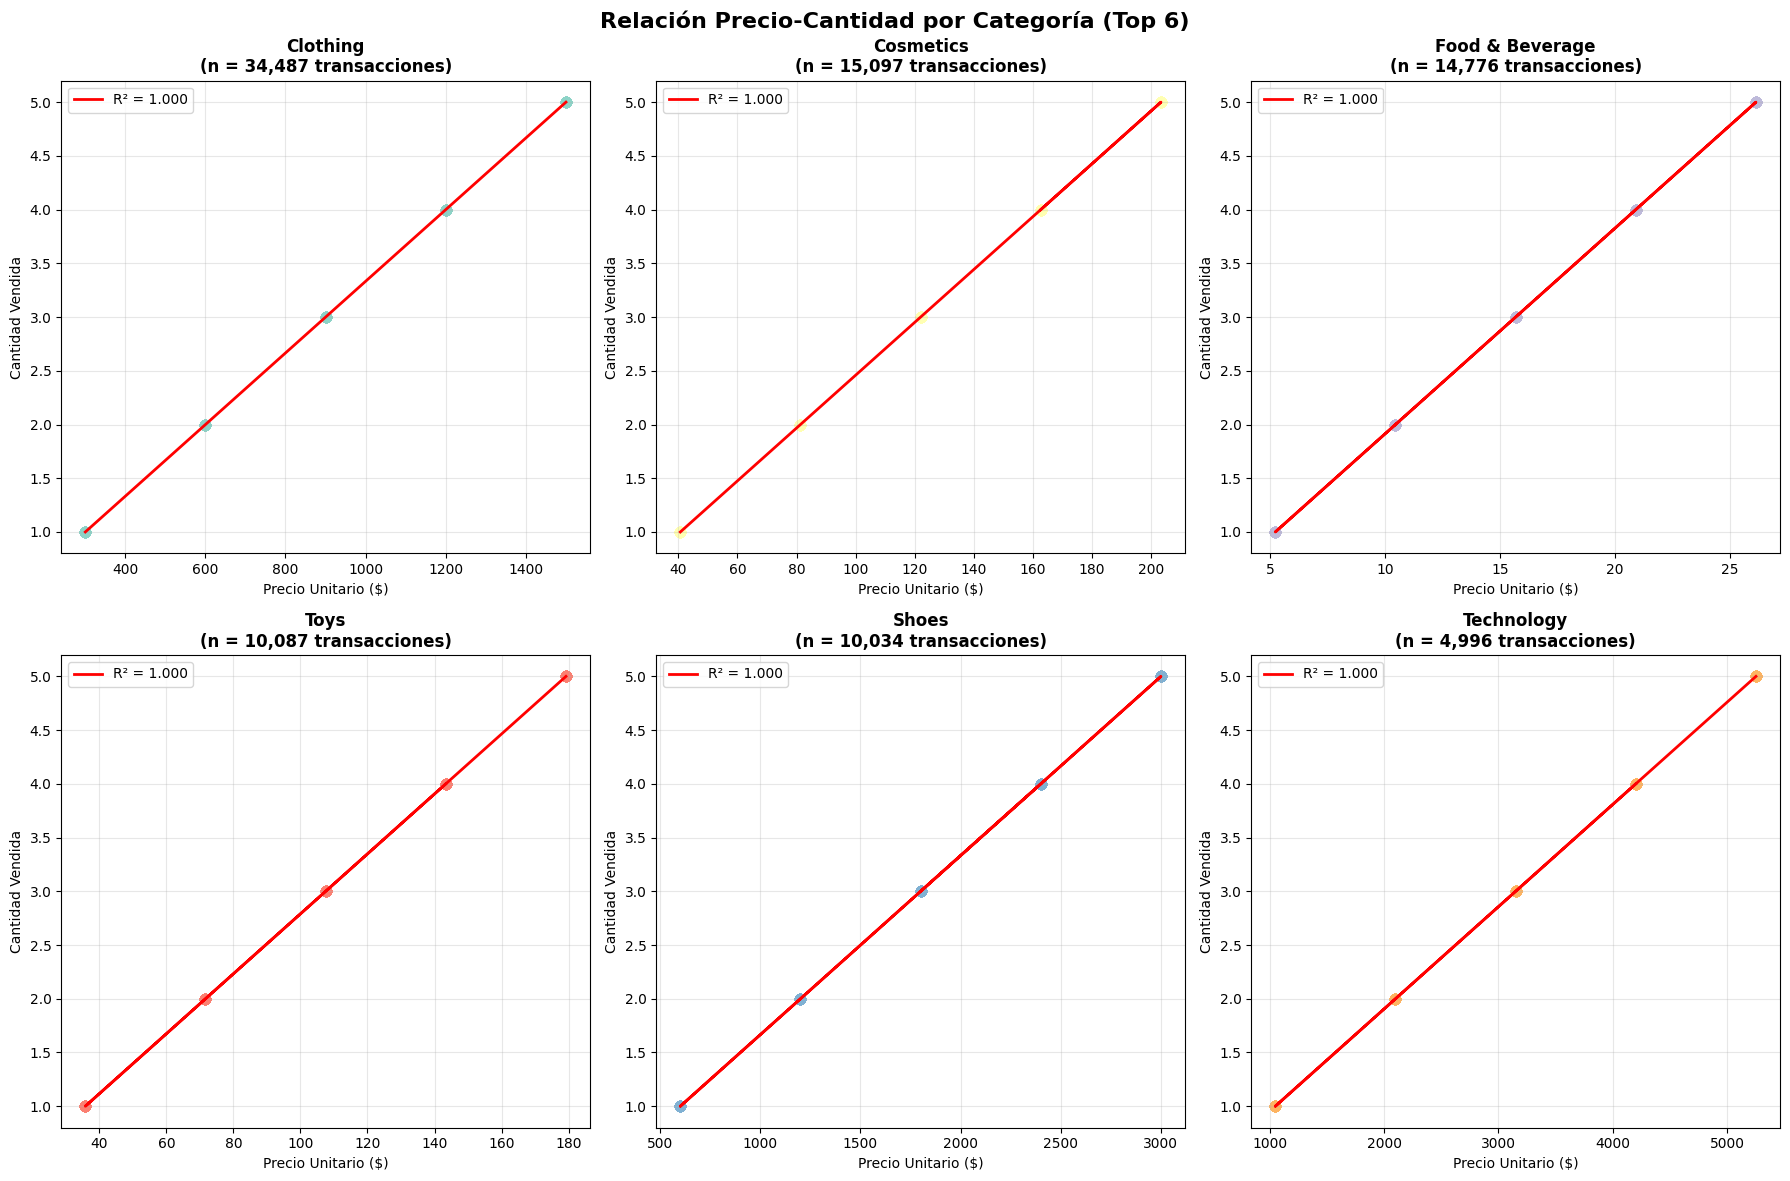

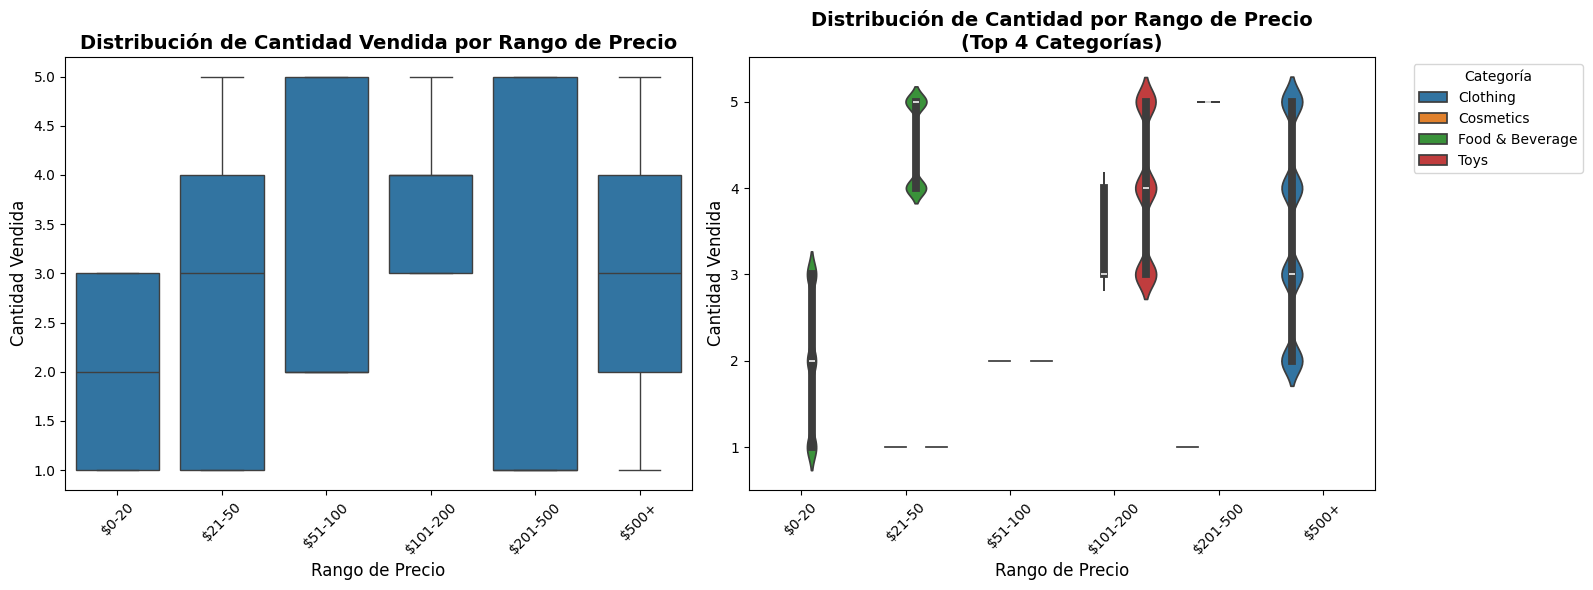

In [64]:
# Análisis del impacto del precio unitario en la cantidad vendida por categoría
import numpy as np
from scipy import stats

# 1. GRÁFICOS DE DISPERSIÓN CON REGRESIÓN POR CATEGORÍA
# Obtener las 6 categorías más importantes por volumen de ventas
top_categories = df.groupby('category')['quantity'].sum().nlargest(6).index

# Crear subplots para gráficos de dispersión
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, category in enumerate(top_categories):
    category_data = df[df['category'] == category]
    
    # Gráfico de dispersión
    axes[i].scatter(category_data['price'], category_data['quantity'], 
                   alpha=0.6, color=plt.cm.Set3(i), s=50)
    
    # Línea de regresión
    if len(category_data) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(category_data['price'], category_data['quantity'])
        line = slope * category_data['price'] + intercept
        axes[i].plot(category_data['price'], line, 'r-', linewidth=2, 
                    label=f'R² = {r_value**2:.3f}')
        axes[i].legend()
    
    axes[i].set_xlabel('Precio Unitario ($)', fontsize=10)
    axes[i].set_ylabel('Cantidad Vendida', fontsize=10)
    axes[i].set_title(f'{category}\n(n = {len(category_data):,} transacciones)', 
                     fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Relación Precio-Cantidad por Categoría (Top 6)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. ANÁLISIS CON RANGOS DE PRECIO (BINNING)
# Crear rangos de precios
df['price_range'] = pd.cut(df['price'], 
                          bins=[0, 20, 50, 100, 200, 500, df['price'].max()],
                          labels=['$0-20', '$21-50', '$51-100', '$101-200', '$201-500', '$500+'])

# Box plots por rangos de precio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot general
sns.boxplot(data=df, x='price_range', y='quantity', ax=ax1)
ax1.set_title('Distribución de Cantidad Vendida por Rango de Precio', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rango de Precio', fontsize=12)
ax1.set_ylabel('Cantidad Vendida', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Violin plot por categoría (top 4 categorías)
top4_categories = df.groupby('category')['quantity'].sum().nlargest(4).index
df_top4 = df[df['category'].isin(top4_categories)]

sns.violinplot(data=df_top4, x='price_range', y='quantity', hue='category', ax=ax2)
ax2.set_title('Distribución de Cantidad por Rango de Precio\n(Top 4 Categorías)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Rango de Precio', fontsize=12)
ax2.set_ylabel('Cantidad Vendida', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 5. ¿Existen diferencias significativas en el gasto promedio por transacción y en las categorías de productos preferidas entre hombres y mujeres de diferentes grupos de edad, y cómo influye el método de pago utilizado en estos patrones de compra?

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:40: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:50: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



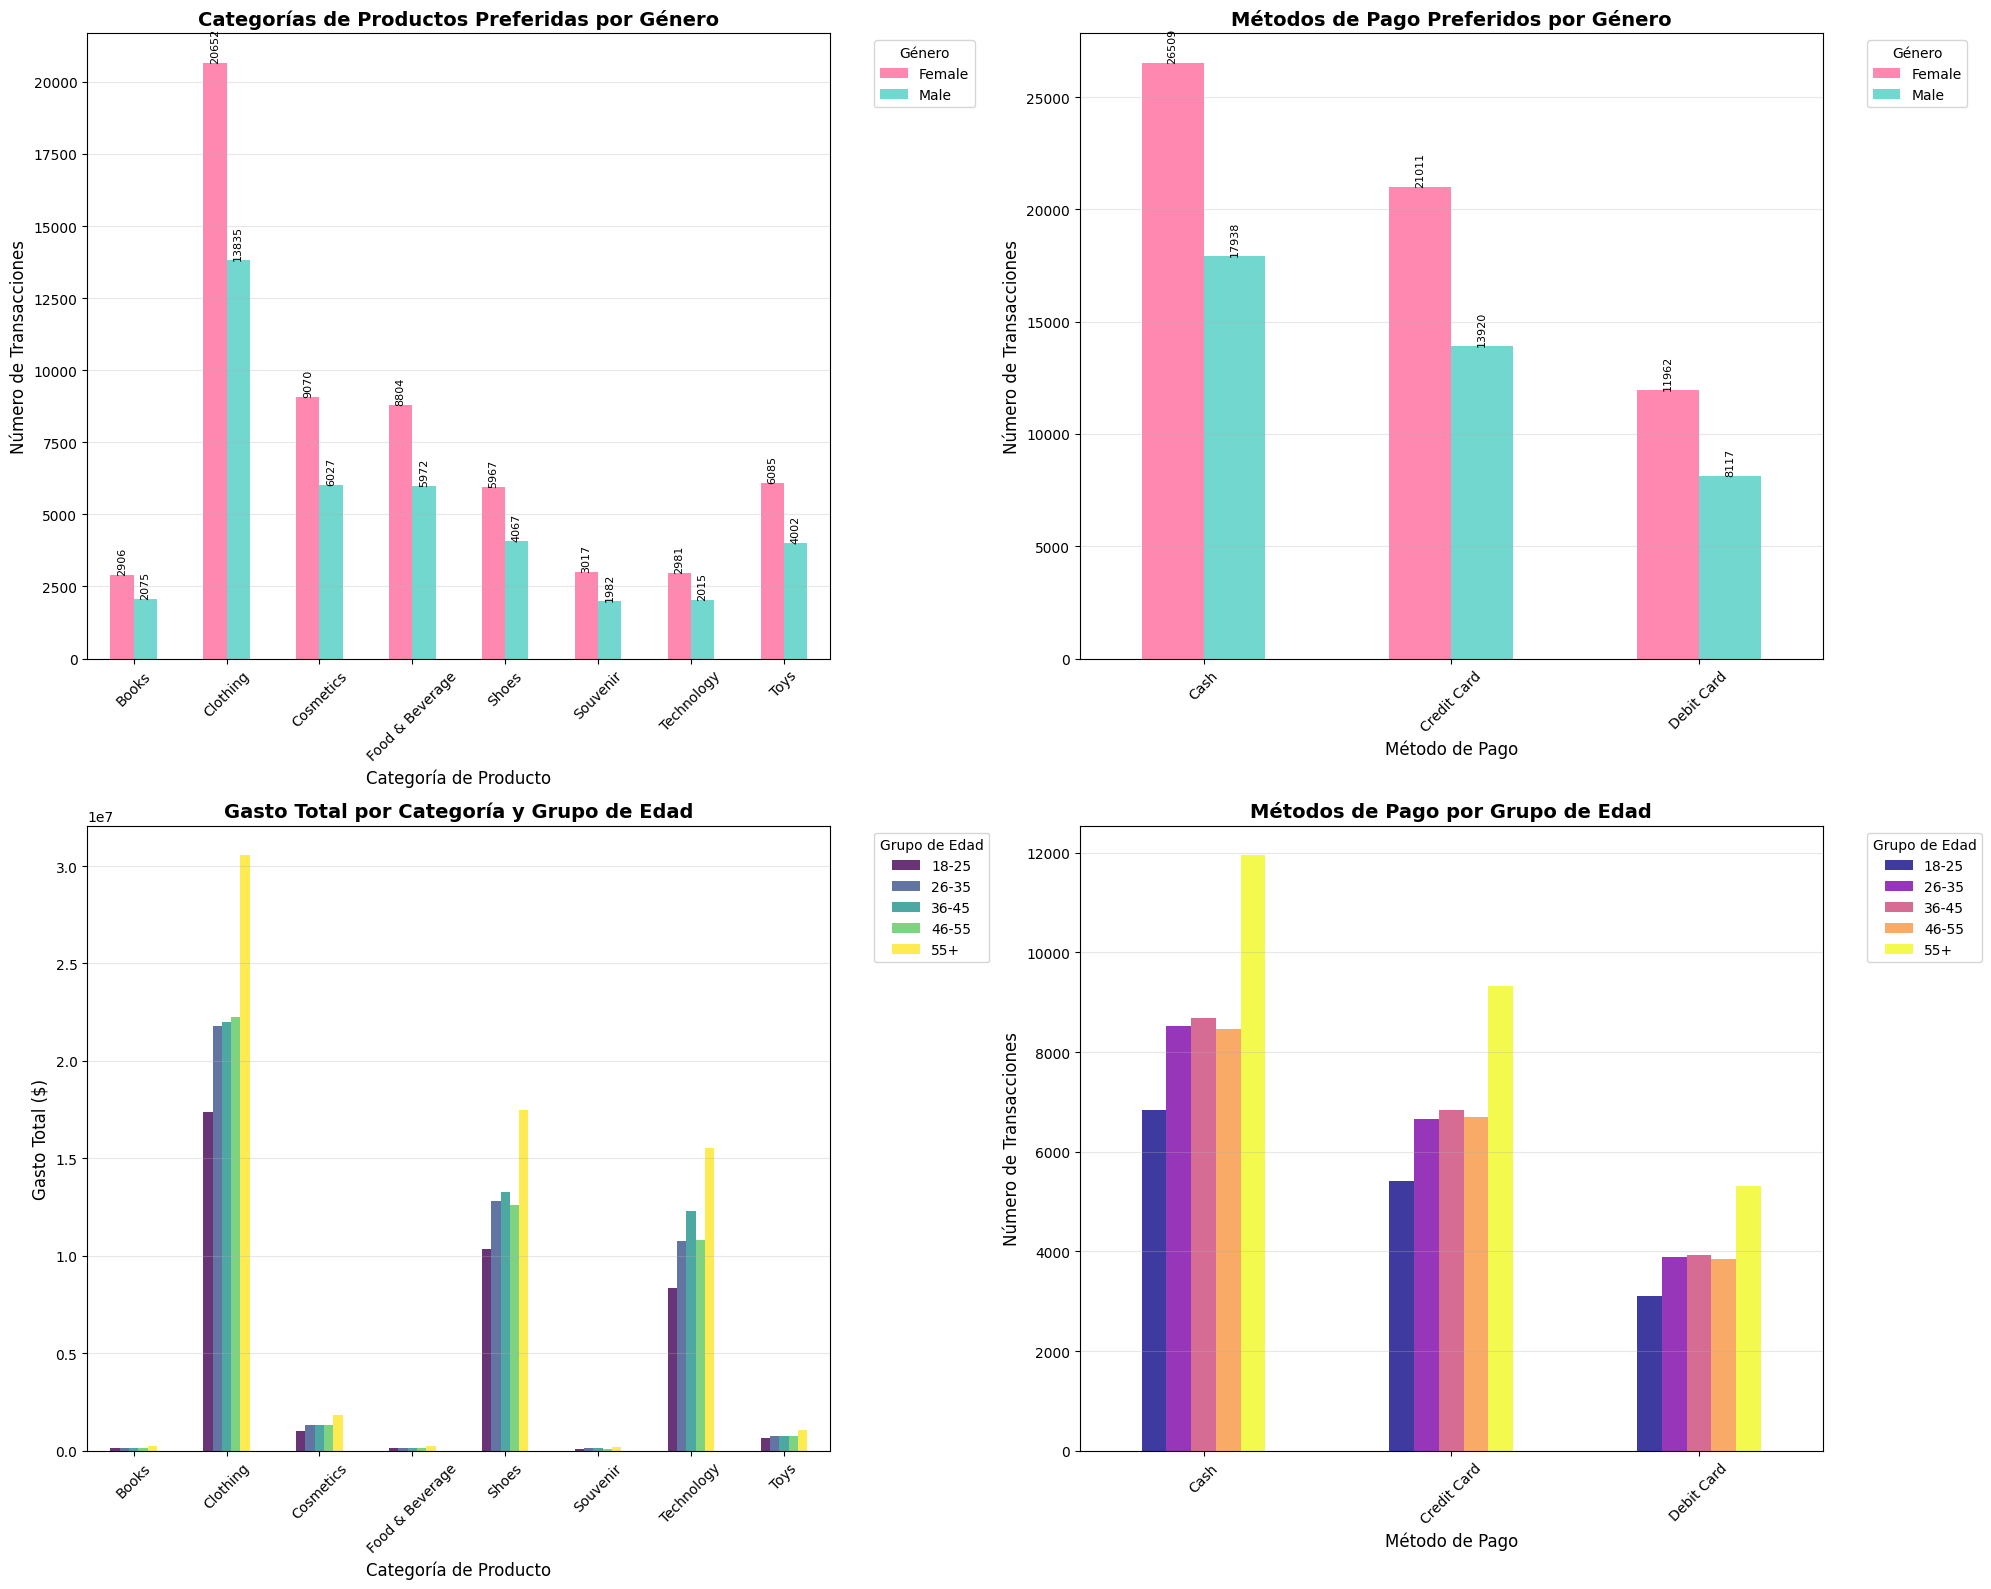

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

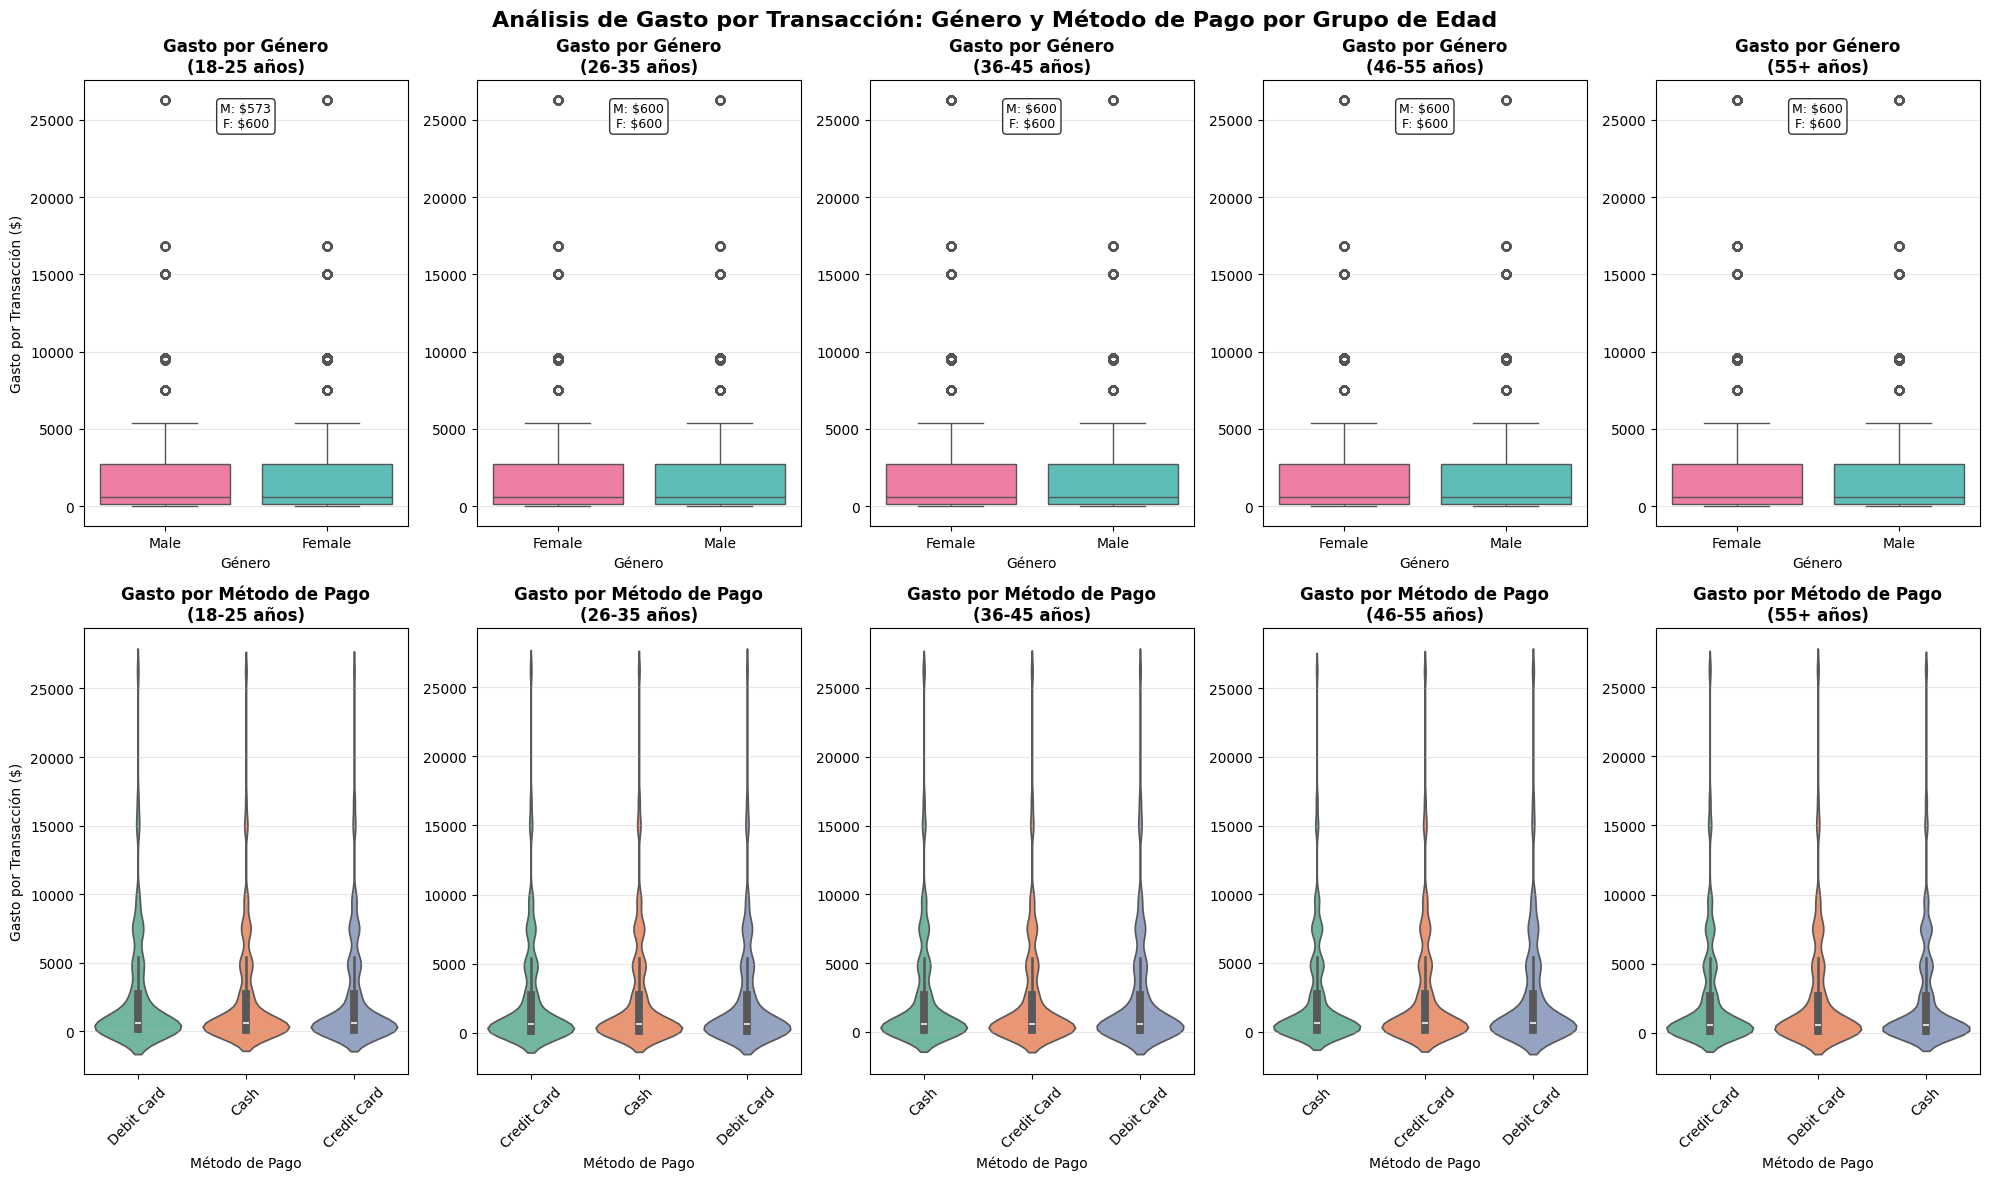


ANÁLISIS ESTADÍSTICO DETALLADO POR DEMOGRAFÍA

1. ANÁLISIS POR GÉNERO:
----------------------------------------
        Gasto_Promedio  Gasto_Mediano  Desv_Std  N_Transacciones  \
gender                                                             
Female         2525.25         600.17   4226.62            59482   
Male           2534.05         600.17   4216.35            39975   

        Cant_Promedio  Precio_Promedio  
gender                                  
Female            3.0           688.14  
Male              3.0           690.92  

2. ANÁLISIS POR GRUPO DE EDAD:
----------------------------------------
           Gasto_Promedio  Gasto_Mediano  N_Transacciones  Cant_Promedio  \
age_group                                                                  
18-25             2481.82         600.17            15359           3.00   
26-35             2512.18         600.17            19059           3.00   
36-45             2582.02         600.17            19436           3.01 

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:125: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:149: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\edang\AppData\Local\Temp\ipykernel_19580\3033155411.py:181: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [65]:
# Análisis de patrones de compra por género, edad y método de pago

# Crear grupos de edad
df['age_group'] = pd.cut(df['age'], 
                        bins=[0, 25, 35, 45, 55, 100], 
                        labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# 1. GRÁFICOS DE BARRAS AGRUPADAS/APILADAS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1.1 Categorías preferidas por género
category_gender = df.groupby(['category', 'gender']).size().unstack(fill_value=0)
ax1_plot = category_gender.plot(kind='bar', ax=ax1, color=['#FF6B9D', '#4ECDC4'], alpha=0.8)
ax1.set_title('Categorías de Productos Preferidas por Género', fontsize=14, fontweight='bold')
ax1.set_xlabel('Categoría de Producto', fontsize=12)
ax1.set_ylabel('Número de Transacciones', fontsize=12)
ax1.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for container in ax1.containers:
    ax1.bar_label(container, rotation=90, fontsize=8)

# 1.2 Métodos de pago por género
payment_gender = df.groupby(['payment_method', 'gender']).size().unstack(fill_value=0)
ax2_plot = payment_gender.plot(kind='bar', ax=ax2, color=['#FF6B9D', '#4ECDC4'], alpha=0.8)
ax2.set_title('Métodos de Pago Preferidos por Género', fontsize=14, fontweight='bold')
ax2.set_xlabel('Método de Pago', fontsize=12)
ax2.set_ylabel('Número de Transacciones', fontsize=12)
ax2.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for container in ax2.containers:
    ax2.bar_label(container, rotation=90, fontsize=8)

# 1.3 Gasto total por categoría y grupo de edad
category_age_spending = df.groupby(['category', 'age_group'])['total'].sum().unstack(fill_value=0)
ax3_plot = category_age_spending.plot(kind='bar', ax=ax3, colormap='viridis', alpha=0.8)
ax3.set_title('Gasto Total por Categoría y Grupo de Edad', fontsize=14, fontweight='bold')
ax3.set_xlabel('Categoría de Producto', fontsize=12)
ax3.set_ylabel('Gasto Total ($)', fontsize=12)
ax3.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 1.4 Métodos de pago por grupo de edad
payment_age = df.groupby(['payment_method', 'age_group']).size().unstack(fill_value=0)
ax4_plot = payment_age.plot(kind='bar', ax=ax4, colormap='plasma', alpha=0.8)
ax4.set_title('Métodos de Pago por Grupo de Edad', fontsize=14, fontweight='bold')
ax4.set_xlabel('Método de Pago', fontsize=12)
ax4.set_ylabel('Número de Transacciones', fontsize=12)
ax4.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. GRÁFICOS DE CAJA Y VIOLÍN CON FACETAS POR GRUPO DE EDAD
# Crear figura para box plots con facetas
age_groups = df['age_group'].cat.categories
n_age_groups = len(age_groups)

fig, axes = plt.subplots(2, n_age_groups, figsize=(20, 12))
fig.suptitle('Análisis de Gasto por Transacción: Género y Método de Pago por Grupo de Edad', 
             fontsize=16, fontweight='bold')

# 2.1 Box plots de gasto por género, facetado por grupo de edad
for i, age_group in enumerate(age_groups):
    age_data = df[df['age_group'] == age_group]
    if len(age_data) > 0:
        sns.boxplot(data=age_data, x='gender', y='total', ax=axes[0, i], 
                   palette=['#FF6B9D', '#4ECDC4'])
        axes[0, i].set_title(f'Gasto por Género\n({age_group} años)', fontsize=12, fontweight='bold')
        axes[0, i].set_xlabel('Género', fontsize=10)
        axes[0, i].set_ylabel('Gasto por Transacción ($)' if i == 0 else '', fontsize=10)
        axes[0, i].grid(axis='y', alpha=0.3)
        
        # Agregar estadísticas descriptivas
        median_male = age_data[age_data['gender'] == 'Male']['total'].median()
        median_female = age_data[age_data['gender'] == 'Female']['total'].median()
        axes[0, i].text(0.5, 0.95, f'M: ${median_male:.0f}\nF: ${median_female:.0f}', 
                       transform=axes[0, i].transAxes, ha='center', va='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=9)

# 2.2 Violin plots de gasto por método de pago, facetado por grupo de edad
for i, age_group in enumerate(age_groups):
    age_data = df[df['age_group'] == age_group]
    if len(age_data) > 0:
        sns.violinplot(data=age_data, x='payment_method', y='total', ax=axes[1, i], 
                      palette='Set2')
        axes[1, i].set_title(f'Gasto por Método de Pago\n({age_group} años)', fontsize=12, fontweight='bold')
        axes[1, i].set_xlabel('Método de Pago', fontsize=10)
        axes[1, i].set_ylabel('Gasto por Transacción ($)' if i == 0 else '', fontsize=10)
        axes[1, i].tick_params(axis='x', rotation=45)
        axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. ANÁLISIS ESTADÍSTICO DETALLADO
print("\n" + "="*80)
print("ANÁLISIS ESTADÍSTICO DETALLADO POR DEMOGRAFÍA")
print("="*80)

# 3.1 Estadísticas por género
print("\n1. ANÁLISIS POR GÉNERO:")
print("-" * 40)
gender_stats = df.groupby('gender').agg({
    'total': ['mean', 'median', 'std', 'count'],
    'quantity': 'mean',
    'price': 'mean'
}).round(2)

gender_stats.columns = ['Gasto_Promedio', 'Gasto_Mediano', 'Desv_Std', 'N_Transacciones', 'Cant_Promedio', 'Precio_Promedio']
print(gender_stats)

# 3.2 Estadísticas por grupo de edad
print("\n2. ANÁLISIS POR GRUPO DE EDAD:")
print("-" * 40)
age_stats = df.groupby('age_group').agg({
    'total': ['mean', 'median', 'count'],
    'quantity': 'mean',
    'price': 'mean'
}).round(2)

age_stats.columns = ['Gasto_Promedio', 'Gasto_Mediano', 'N_Transacciones', 'Cant_Promedio', 'Precio_Promedio']
print(age_stats)

# 3.3 Estadísticas por método de pago
print("\n3. ANÁLISIS POR MÉTODO DE PAGO:")
print("-" * 40)
payment_stats = df.groupby('payment_method').agg({
    'total': ['mean', 'median', 'count'],
    'quantity': 'mean',
    'price': 'mean'
}).round(2)

payment_stats.columns = ['Gasto_Promedio', 'Gasto_Mediano', 'N_Transacciones', 'Cant_Promedio', 'Precio_Promedio']
print(payment_stats)

# 3.4 Análisis cruzado: Género x Grupo de Edad
print("\n4. ANÁLISIS CRUZADO: GÉNERO x GRUPO DE EDAD")
print("-" * 40)
cross_analysis = df.groupby(['gender', 'age_group'])['total'].agg(['mean', 'count']).round(2)
print(cross_analysis)

# 3.5 Categorías más populares por género
print("\n5. TOP 3 CATEGORÍAS POR GÉNERO:")
print("-" * 40)
for gender in df['gender'].unique():
    top_categories = df[df['gender'] == gender]['category'].value_counts().head(3)
    print(f"\n{gender.upper()}:")
    for i, (category, count) in enumerate(top_categories.items(), 1):
        print(f"  {i}. {category}: {count:,} transacciones")

# 3.6 Análisis de significancia estadística
from scipy import stats as scipy_stats

print("\n6. PRUEBAS DE SIGNIFICANCIA ESTADÍSTICA:")
print("-" * 40)

# Test t para diferencias de gasto entre géneros
male_spending = df[df['gender'] == 'Male']['total']
female_spending = df[df['gender'] == 'Female']['total']
t_stat, p_value = scipy_stats.ttest_ind(male_spending, female_spending)

print(f"\nTest t para diferencias de gasto entre géneros:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✓ Existe diferencia significativa en el gasto entre géneros")
else:
    print("✗ No existe diferencia significativa en el gasto entre géneros")

# ANOVA para diferencias entre grupos de edad
age_groups_data = [group['total'].values for name, group in df.groupby('age_group')]
f_stat, p_value_anova = scipy_stats.f_oneway(*age_groups_data)

print(f"\nANOVA para diferencias entre grupos de edad:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value_anova:.4f}")
if p_value_anova < 0.05:
    print("✓ Existe diferencia significativa en el gasto entre grupos de edad")
else:
    print("✗ No existe diferencia significativa en el gasto entre grupos de edad")